# 04. 분류 모델 (Classification Trials)

회귀로는 폐업률 예측이 어려워, **폐업률 상위 구간을 '위험'으로 보는 이진 분류**로 문제를 재정의했다.
optuna 튜닝 이전의 기본 분류 실험을 네 가지 트리 모델로 정리한다. 각 섹션은 독립 실행된다.

| 모델 | 라벨 기준 | 인코딩 | 특징 |
|------|-----------|--------|------|
| RandomForest | quantile(0.5)·평균 | LabelEncoding + 파생변수 | RandomizedSearch |
| CatBoost | median·quantile(0.7) 등 | OneHot | threshold/quantile 탐색 |
| XGBoost | quantile(0.7)·평균 | LabelEncoding + 파생변수 | GridSearch |
| LightGBM | 분기별 상위25% t+1 시프트 | category | 시계열 라벨·early stopping |

> optuna/SMOTE로 튜닝한 최종 버전은 `05`에서 다룬다.

## 0. 공통 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib
font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/eda/merged_data.csv'

## 1. RandomForest Classifier

파생변수 추가 후 폐업률 상위 50% 기준 이진 분류, RandomizedSearch로 튜닝한다.

In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint

def add_features(df):
    """RF/XGB 섹션 공통 파생변수 생성."""
    df['건당_매출액'] = df['당월_매출_금액'] / (df['당월_매출_건수'] + 1e-6)
    df['주중_매출_금액'] = df['월요일_매출_금액'] + df['화요일_매출_금액'] + df['수요일_매출_금액'] + df['목요일_매출_금액'] + df['금요일_매출_금액']
    df['주말_매출_금액'] = df['토요일_매출_금액'] + df['일요일_매출_금액']
    df['주중_매출_비율'] = df['주중_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['주말_매출_비율'] = df['주말_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['저녁시간_매출_비율'] = df['시간대_17_21_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['여성_매출_비율'] = df['여성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['남성_매출_비율'] = df['남성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['유동인구_대비_상주인구_비율'] = df['총_상주인구_수'] / (df['총_유동인구_수'] + 1e-6)
    df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
    df['분기'] = df['기준_년분기_코드'].astype(str).str[4:].astype(int)
    df = df.sort_values(by=['자치구_코드_명', '서비스_업종_코드_명', '연도', '분기'])
    df['전년_당월_매출액'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['당월_매출_금액'].shift(4)
    df['전년_유사_업종_점포_수'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['유사_업종_점포_수'].shift(4)
    df['당월매출증감'] = df['당월_매출_금액'] - df['전년_당월_매출액']
    df['유사업종점포수증감'] = df['유사_업종_점포_수'] - df['전년_유사_업종_점포_수']
    for c in ['당월매출증감', '유사업종점포수증감', '전년_당월_매출액', '전년_유사_업종_점포_수']:
        df[c] = df[c].fillna(df[c].mean())
    return df

# 세부 인구/지출/유동 컬럼 (다중공선성 정리용)
DETAIL_COLS = [
    '남성_유동인구_수', '여성_유동인구_수',
    '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수',
    '연령대_10_직장인구_수', '연령대_20_직장인구_수', '연령대_30_직장인구_수',
    '연령대_40_직장인구_수', '연령대_50_직장인구_수', '연령대_60_이상_직장인구_수',
    '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수',
    '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수',
    '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수',
    '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수',
    '남성_상주인구_수', '여성_상주인구_수',
    '연령대_10_미만_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
    '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
    '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
    '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
    '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
    '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수',
    '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액',
    '교통_지출_총금액', '교육_지출_총금액', '유흥_지출_총금액', '여가_문화_지출_총금액',
]

In [3]:
df = pd.read_csv(DATA_PATH)
df = df.drop(['폐업_점포_수', '폐업_영업_개월_평균', '서울시_폐업_영업_개월_평균'], axis=1)

# 레이블 인코딩
for col in ['자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표']:
    df[col] = LabelEncoder().fit_transform(df[col])

df = add_features(df)
df = df.drop(DETAIL_COLS, axis=1)

C:\Users\kouls\AppData\Local\Temp\ipykernel_7420\4016043266.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['건당_매출액'] = df['당월_매출_금액'] / (df['당월_매출_건수'] + 1e-6)
C:\Users\kouls\AppData\Local\Temp\ipykernel_7420\4016043266.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['주중_매출_금액'] = df['월요일_매출_금액'] + df['화요일_매출_금액'] + df['수요일_매출_금액'] + df['목요일_매출_금액'] + df['금요일_매출_금액']
C:\Users\kouls\AppData\Local\Temp\ipykernel_7420\4016043266.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

In [4]:
# 폐업률 상위 50% 기준 이진 분류
df['폐업률_등급'] = pd.qcut(df['폐업_률'], q=[0, 0.5, 1.0], labels=[0, 1])
X = df.drop(['폐업_률', '폐업률_등급'], axis=1)
y_class = df['폐업률_등급']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class)

rf_clf = RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=42)
rf_clf.fit(X_train, y_train)
print('[기본 RF]')
print(classification_report(y_test, rf_clf.predict(X_test), target_names=['안정', '위험']))

[기본 RF]
              precision    recall  f1-score   support

          안정       0.73      0.80      0.76      4111
          위험       0.76      0.68      0.72      3884

    accuracy                           0.74      7995
   macro avg       0.74      0.74      0.74      7995
weighted avg       0.74      0.74      0.74      7995



In [5]:
# RandomizedSearch (탐색 축소)
param_distributions = {
    'n_estimators': randint(120, 320),
    'max_depth': [None, 10, 14],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': randint(1, 5),
}
rnd = RandomizedSearchCV(rf_clf, param_distributions, n_iter=8, cv=3,
                         scoring='accuracy', n_jobs=-1, random_state=42)
rnd.fit(X_train, y_train)
print('최적 파라미터:', rnd.best_params_)
print('최적 CV 점수:', round(rnd.best_score_, 4))

최적 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 177}
최적 CV 점수: 0.7482


              precision    recall  f1-score   support

          안정       0.73      0.80      0.76      4111
          위험       0.77      0.68      0.72      3884

    accuracy                           0.74      7995
   macro avg       0.75      0.74      0.74      7995
weighted avg       0.75      0.74      0.74      7995



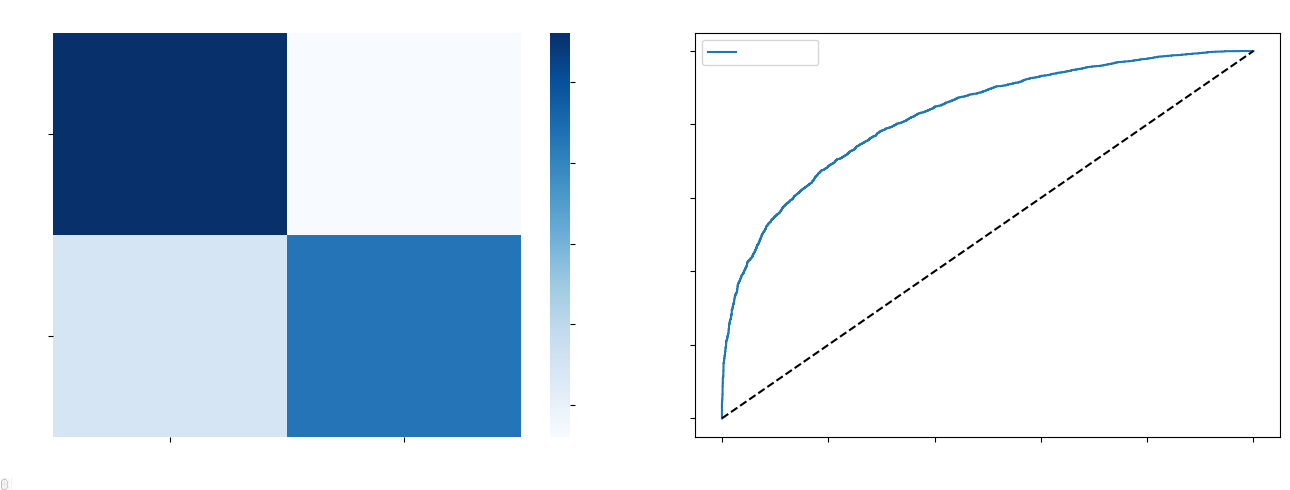

In [6]:
best_rf = rnd.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['안정', '위험']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['안정', '위험'], yticklabels=['안정', '위험'], ax=axes[0])
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('실제값'); axes[0].set_title('RF Confusion Matrix')

y_prob = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.2f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('RF ROC'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. CatBoost Classifier

OneHot 인코딩 후 여러 분위수 기준으로 이진 분류를 실험하고, threshold를 조정한다.

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

df = pd.read_csv(DATA_PATH)
df = df.drop('폐업_점포_수', axis=1)

X = df.drop('폐업_률', axis=1)
y = df['폐업_률']

# OneHot 인코딩
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = [c for c in X.columns if c not in categorical_cols]
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=X.index)
X_encoded = pd.concat([X[numerical_cols], encoded_df], axis=1)

X_train, X_valid = train_test_split(X_encoded, random_state=42)

C:\Users\kouls\AppData\Local\Temp\ipykernel_7420\1811144220.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


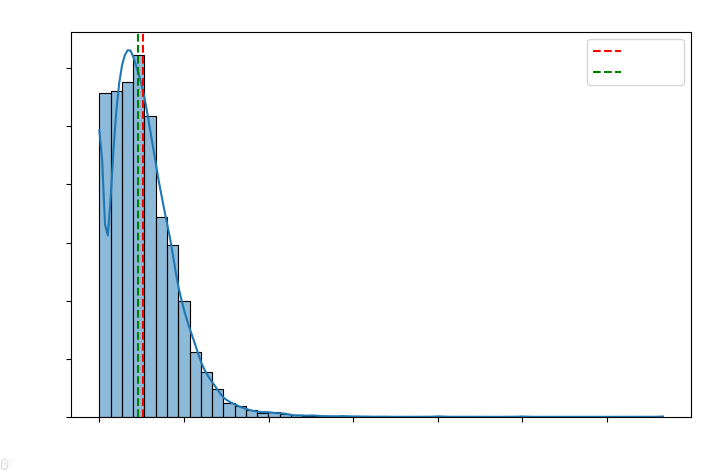

In [8]:
# 폐업률 분포
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True)
plt.axvline(y.mean(), color='r', linestyle='--', label='Mean')
plt.axvline(y.median(), color='g', linestyle='--', label='Median')
plt.title('폐업률 분포'); plt.xlabel('폐업률'); plt.ylabel('Count'); plt.legend()
plt.show()

In [9]:
# 상위 30% 기준 이진 분류
threshold = y.quantile(0.7)
y_binary = (y > threshold).astype(int)
y_train_bin, y_valid_bin = train_test_split(y_binary, random_state=42)

model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6,
                           eval_metric='Accuracy', verbose=200, random_seed=42)
model.fit(X_train, y_train_bin, eval_set=(X_valid, y_valid_bin), early_stopping_rounds=50)

y_pred = model.predict(X_valid)
print(classification_report(y_valid_bin, y_pred))

0:	learn: 0.7754578	test: 0.7624575	best: 0.7624575 (0)	total: 196ms	remaining: 3m 15s


200:	learn: 0.8273907	test: 0.7950770	best: 0.7955773 (195)	total: 10.1s	remaining: 40s


400:	learn: 0.8561422	test: 0.7984791	best: 0.7999800 (391)	total: 19.5s	remaining: 29.1s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8017810686
bestIteration = 472

Shrink model to first 473 iterations.
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      7084
           1       0.71      0.53      0.61      2910

    accuracy                           0.80      9994
   macro avg       0.77      0.72      0.74      9994
weighted avg       0.79      0.80      0.79      9994



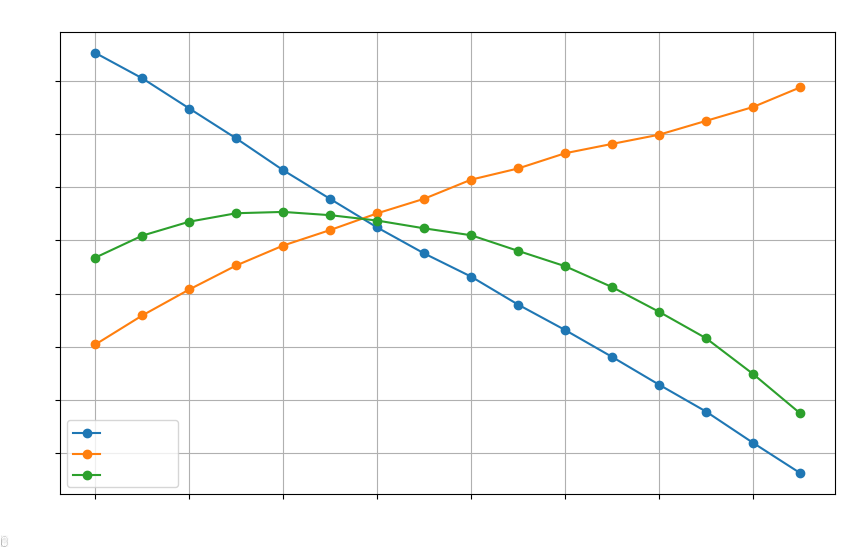

In [10]:
# threshold 조정: F1 기준 탐색
y_probs = model.predict_proba(X_valid)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []
for t in thresholds:
    rep = classification_report(y_valid_bin, (y_probs >= t).astype(int), output_dict=True, zero_division=0)
    recalls.append(rep['1']['recall']); precisions.append(rep['1']['precision']); f1s.append(rep['1']['f1-score'])

plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls, label='Recall', marker='o')
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, f1s, label='F1', marker='o')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Precision/Recall/F1 vs Threshold')
plt.legend(); plt.grid(True); plt.show()

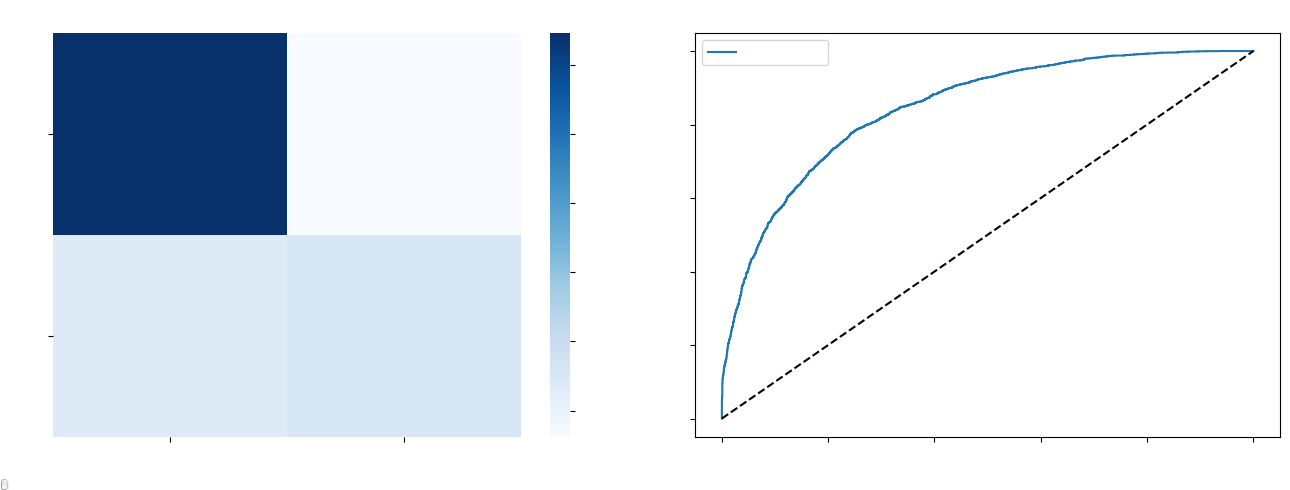

In [11]:
# 혼동행렬 / ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_valid_bin, model.predict(X_valid))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('CatBoost Confusion Matrix')

fpr, tpr, _ = roc_curve(y_valid_bin, y_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_valid_bin, y_probs):.2f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('CatBoost ROC'); axes[1].legend()
plt.tight_layout(); plt.show()

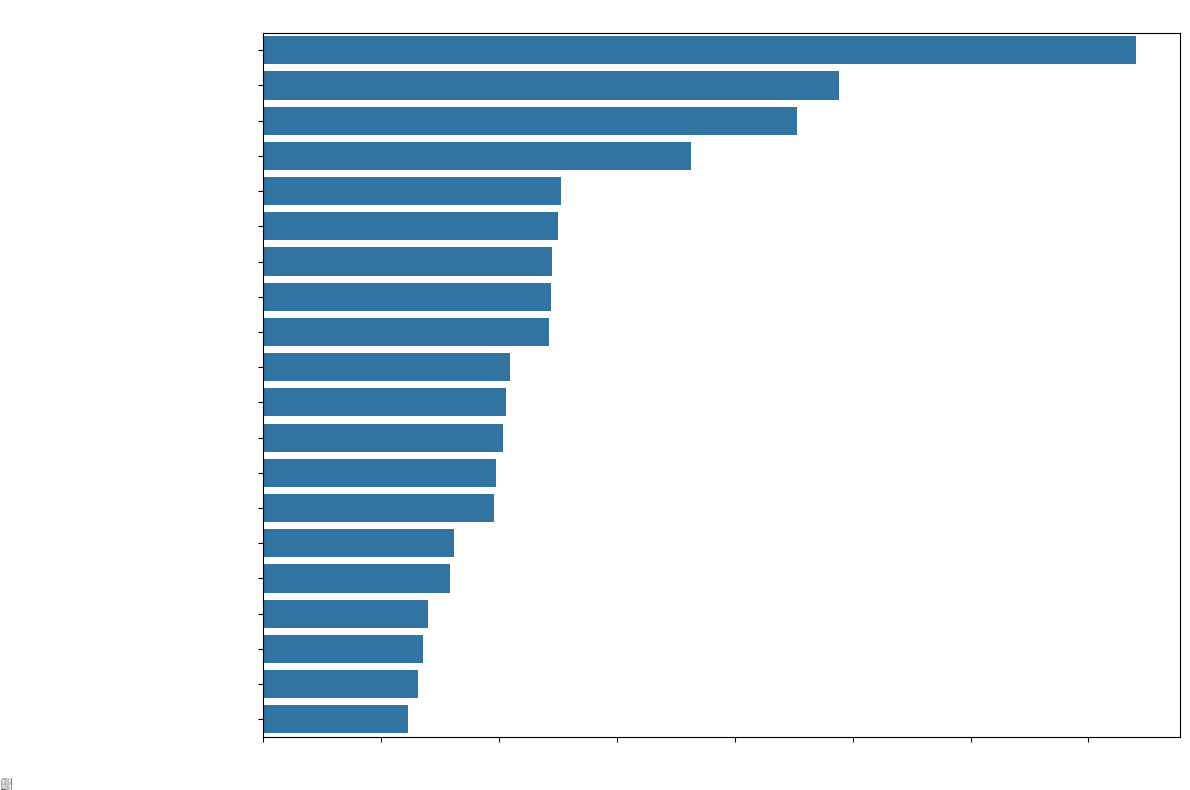

In [12]:
# 특성 중요도 (Top 20)
importances_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(data=importances_df.head(20), x='Importance', y='Feature')
plt.title('CatBoost 특성 중요도 (Top 20)')
plt.tight_layout(); plt.show()

## 3. XGBoost Classifier

파생변수 추가 + 폐업률 상위 70% 기준, SMOTE 적용 및 GridSearch로 튜닝한다.

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

def add_features(df):
    """RF/XGB 섹션 공통 파생변수 생성."""
    df['건당_매출액'] = df['당월_매출_금액'] / (df['당월_매출_건수'] + 1e-6)
    df['주중_매출_금액'] = df['월요일_매출_금액'] + df['화요일_매출_금액'] + df['수요일_매출_금액'] + df['목요일_매출_금액'] + df['금요일_매출_금액']
    df['주말_매출_금액'] = df['토요일_매출_금액'] + df['일요일_매출_금액']
    df['주중_매출_비율'] = df['주중_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['주말_매출_비율'] = df['주말_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['저녁시간_매출_비율'] = df['시간대_17_21_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['여성_매출_비율'] = df['여성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['남성_매출_비율'] = df['남성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
    df['유동인구_대비_상주인구_비율'] = df['총_상주인구_수'] / (df['총_유동인구_수'] + 1e-6)
    df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
    df['분기'] = df['기준_년분기_코드'].astype(str).str[4:].astype(int)
    df = df.sort_values(by=['자치구_코드_명', '서비스_업종_코드_명', '연도', '분기'])
    df['전년_당월_매출액'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['당월_매출_금액'].shift(4)
    df['전년_유사_업종_점포_수'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['유사_업종_점포_수'].shift(4)
    df['당월매출증감'] = df['당월_매출_금액'] - df['전년_당월_매출액']
    df['유사업종점포수증감'] = df['유사_업종_점포_수'] - df['전년_유사_업종_점포_수']
    for c in ['당월매출증감', '유사업종점포수증감', '전년_당월_매출액', '전년_유사_업종_점포_수']:
        df[c] = df[c].fillna(df[c].mean())
    return df

# 세부 인구/지출/유동 컬럼 (다중공선성 정리용)
DETAIL_COLS = [
    '남성_유동인구_수', '여성_유동인구_수',
    '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수',
    '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수',
    '연령대_10_직장인구_수', '연령대_20_직장인구_수', '연령대_30_직장인구_수',
    '연령대_40_직장인구_수', '연령대_50_직장인구_수', '연령대_60_이상_직장인구_수',
    '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수',
    '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수',
    '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수',
    '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수',
    '남성_상주인구_수', '여성_상주인구_수',
    '연령대_10_미만_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
    '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
    '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
    '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
    '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
    '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수',
    '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액',
    '교통_지출_총금액', '교육_지출_총금액', '유흥_지출_총금액', '여가_문화_지출_총금액',
]

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.drop(['폐업_점포_수', '폐업_영업_개월_평균', '서울시_폐업_영업_개월_평균'], axis=1)

for col in ['자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표']:
    df[col] = LabelEncoder().fit_transform(df[col])

df = add_features(df)
df = df.drop(DETAIL_COLS, axis=1)

In [ ]:
# 상위 70% 기준 + SMOTE
df['폐업률_등급'] = pd.qcut(df['폐업_률'], q=[0, 0.7, 1.0], labels=[0, 1])
X = df.drop(['폐업_률', '폐업률_등급'], axis=1)
y_class = df['폐업률_등급']

X_res, y_res = SMOTE(random_state=42).fit_resample(X, y_class)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                        subsample=0.9, colsample_bytree=0.7, random_state=42)
xgb_clf.fit(X_train, y_train)
print('[기본 XGB]')
print(classification_report(y_test, xgb_clf.predict(X_test), target_names=['안정', '위험']))

In [ ]:
# GridSearch (탐색 축소)
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8],
}
grid = GridSearchCV(XGBClassifier(subsample=0.9, colsample_bytree=0.9, random_state=42),
                    param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('최적 파라미터:', grid.best_params_)
print('최적 CV 점수:', round(grid.best_score_, 4))

In [ ]:
best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['안정', '위험']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['안정(0)', '위험(1)'], yticklabels=['안정(0)', '위험(1)'], ax=axes[0])
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('실제값'); axes[0].set_title('XGBoost Confusion Matrix')

y_prob = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='blue', label=f'AUC={auc(fpr, tpr):.2f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('XGBoost ROC'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# 특성 중요도
feature_importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values()
feature_importance.tail(20).plot(kind='barh', figsize=(8, 8))
plt.title('XGBoost 특성 중요도 (Top 20)')
plt.tight_layout(); plt.show()

## 4. LightGBM Classifier (시계열 라벨)

분기별 상위 25%를 '위험'으로 보고 **다음 분기 라벨로 시프트**하여 미래 예측 구조로 학습한다. 분할도 최신 분기를 테스트로 두는 시계열 방식이다.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score, f1_score)

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.drop(columns=['폐업_점포_수', '운영_영업_개월_평균', '폐업_영업_개월_평균',
                      '서울시_운영_영업_개월_평균', '서울시_폐업_영업_개월_평균'])
print(df.shape)

In [ ]:
# 분기별 상위 25% → 다음 분기 라벨(t+1)
KEY_Q, KEY_G, KEY_S, TARGET = '기준_년분기_코드', '자치구_코드_명', '서비스_업종_코드_명', '폐업_률'
df = df.sort_values([KEY_G, KEY_S, KEY_Q]).copy()
q75 = df.groupby(KEY_Q)[TARGET].quantile(0.75).rename('thr')
df = df.merge(q75, left_on=KEY_Q, right_index=True, how='left')
df['is_high_t'] = (df[TARGET] >= df['thr']).astype(int)
df['y'] = df.groupby([KEY_G, KEY_S])['is_high_t'].shift(-1)
df = df[df['y'].notna()].copy()
df['y'] = df['y'].astype(int)
print('라벨 분포:', df['y'].value_counts().to_dict())

In [ ]:
# 피처 선택
base_exclude = {TARGET, 'thr', 'is_high_t', 'y'}
num_cols = df.select_dtypes(include=[np.number]).columns.difference(base_exclude).tolist()
cat_cols = [c for c in ['자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표'] if c in df.columns]
for c in cat_cols:
    df[c] = df[c].astype('category')

feature_cols = num_cols + cat_cols
X = df[feature_cols]
y = df['y']

In [ ]:
# 분할: 마지막 분기=테스트, 나머지=학습
quarters = sorted(df[KEY_Q].unique())
test_q = quarters[-1]
train_idx = df[df[KEY_Q] != test_q].index
test_idx = df[df[KEY_Q] == test_q].index
X_tr, y_tr = X.loc[train_idx], y.loc[train_idx]
X_te, y_te = X.loc[test_idx], y.loc[test_idx]
print(f'Train: {X_tr.shape}, Test(latest {test_q}): {X_te.shape}')

In [ ]:
model = lgb.LGBMClassifier(
    objective='binary', boosting='gbdt', learning_rate=0.01,
    n_estimators=5000, num_leaves=35, max_depth=12,
    min_data_in_leaf=200, reg_alpha=2.0, min_split_gain=0.05,
    class_weight={0: 1.0, 1: 3.0}, n_jobs=-1,
    feature_fraction=0.8, bagging_fraction=0.9, bagging_freq=1,
    min_child_samples=50, reg_lambda=8.0, verbosity=-1
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    eval_metric=['auc', 'average_precision'],
    categorical_feature=[c for c in cat_cols if c in X.columns],
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

In [ ]:
# 평가 (임계값 0.6)
pred_prob = model.predict_proba(X_te)[:, 1]
pred_label = (pred_prob >= 0.6).astype(int)

print(f'ACC     : {accuracy_score(y_te, pred_label):.4f}')
print(f'PREC    : {precision_score(y_te, pred_label, zero_division=0):.4f}')
print(f'RECALL  : {recall_score(y_te, pred_label, zero_division=0):.4f}')
print(f'F1      : {f1_score(y_te, pred_label, zero_division=0):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_te, pred_prob):.4f}')
print(f'PR-AUC  : {average_precision_score(y_te, pred_prob):.4f}')

In [ ]:
# 중요도 TOP 15 (gain)
imp = pd.DataFrame({
    'feature': X.columns,
    'gain': model.booster_.feature_importance(importance_type='gain')
}).sort_values('gain', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp.head(15), x='gain', y='feature')
plt.title('LightGBM 중요도 TOP 15 (gain)')
plt.tight_layout(); plt.show()

## 정리

네 모델 모두 폐업률 상위 구간을 '위험'으로 보는 이진 분류에서 회귀보다 **의미 있는 성능**을 보였다. 라벨 기준(분위수)·인코딩·불균형 처리(SMOTE)·시계열 라벨 등 여러 접근을 비교했다.

→ `05`에서는 optuna로 하이퍼파라미터를 튜닝하고 SMOTE를 적용한 **최종 분류 모델**을 정리한다.